In [1]:
pip install pandas numpy scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import os, json, pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, precision_recall_curve, average_precision_score
)

sns.set_style("whitegrid")

df_raw = pd.read_csv("Customer-Churn-Records.csv")
print("Shape:", df_raw.shape)
df_raw.head(3)

Shape: (10000, 18)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377


In [3]:
print("Missing values:")
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])

print("\nTarget distribution:")
vc = df_raw["Exited"].value_counts(normalize=True)
print(f"  Stayed  (0): {vc[0]:.1%}")
print(f"  Churned (1): {vc[1]:.1%}")

Missing values:
Series([], dtype: int64)

Target distribution:
  Stayed  (0): 79.6%
  Churned (1): 20.4%


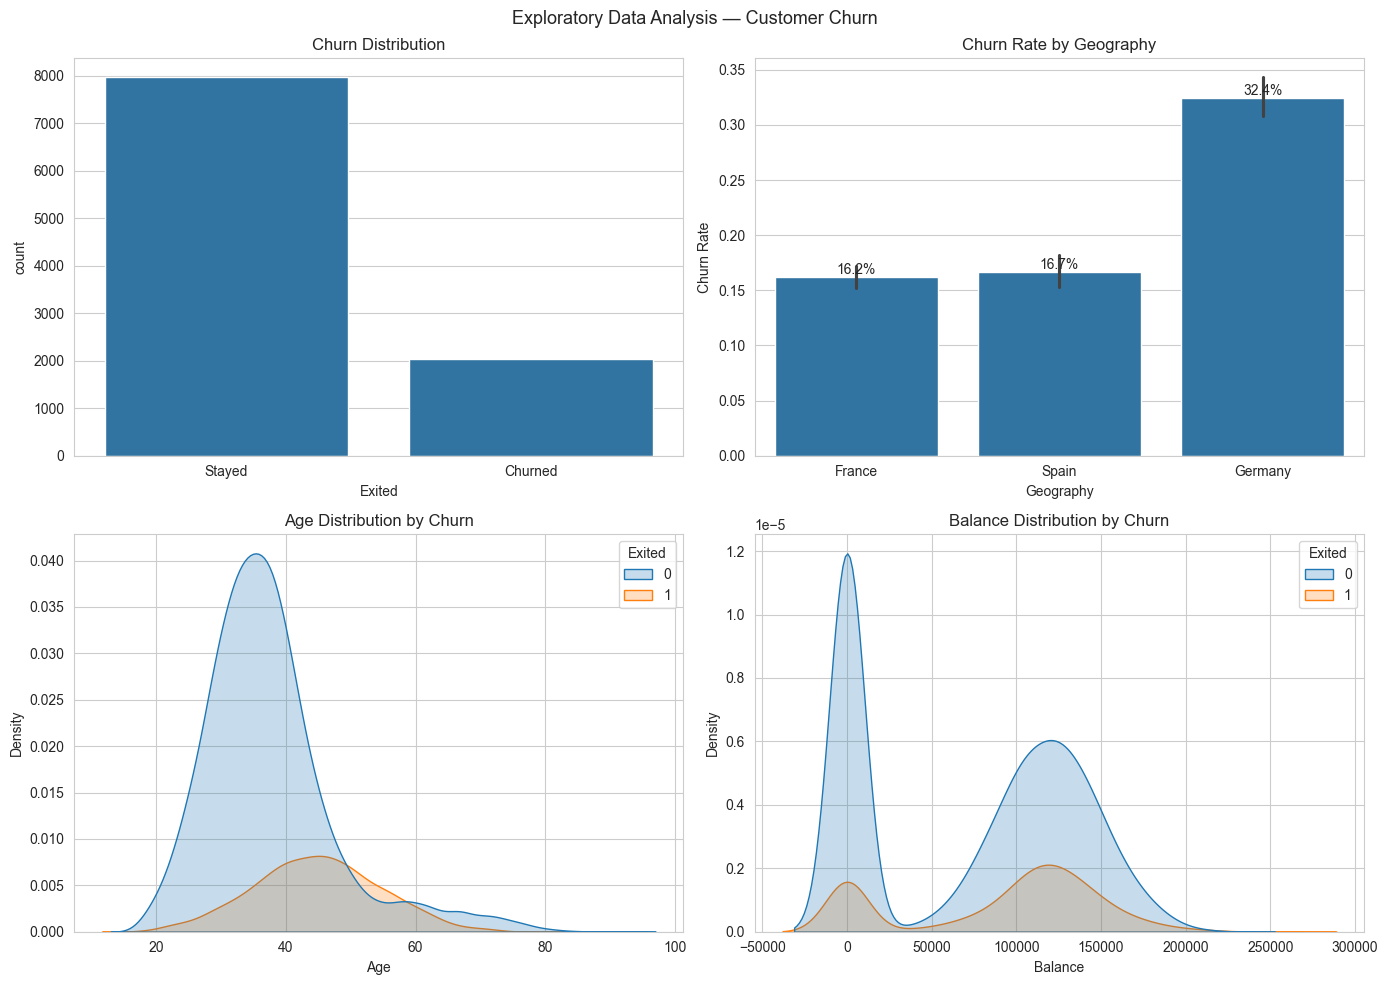

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Churn count
sns.countplot(data=df_raw, x="Exited", ax=axes[0, 0])
axes[0, 0].set_xticks([0, 1])
axes[0, 0].set_xticklabels(["Stayed", "Churned"])
axes[0, 0].set_title("Churn Distribution")

# Churn by geography
ax_geo = sns.barplot(data=df_raw, x="Geography", y="Exited", ax=axes[0, 1])
for p in ax_geo.patches:
    ax_geo.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom"
    )
axes[0, 1].set(title="Churn Rate by Geography", ylabel="Churn Rate")

# Age distribution by churn
sns.kdeplot(data=df_raw, x="Age", hue="Exited", fill=True, ax=axes[1, 0])
axes[1, 0].set_title("Age Distribution by Churn")

# Balance by churn
sns.kdeplot(data=df_raw, x="Balance", hue="Exited", fill=True, ax=axes[1, 1])
axes[1, 1].set_title("Balance Distribution by Churn")

plt.suptitle("Exploratory Data Analysis — Customer Churn", fontsize=13)
plt.tight_layout()
plt.show()

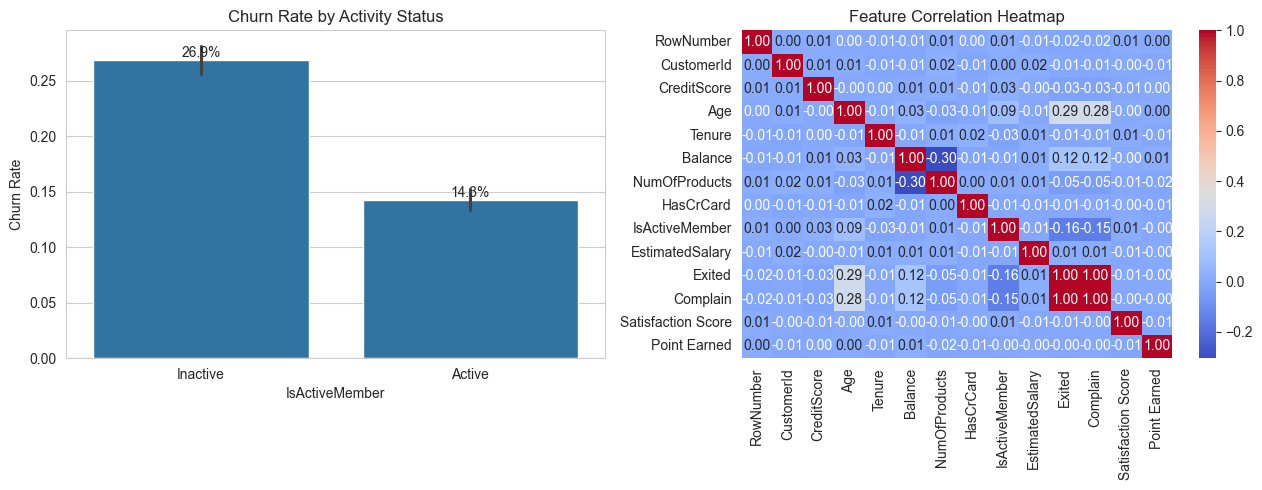

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Churn by activity status
ax_act = sns.barplot(data=df_raw, x="IsActiveMember", y="Exited", ax=axes[0])
ax_act.set_xticklabels(["Inactive", "Active"])
for p in ax_act.patches:
    ax_act.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom"
    )
axes[0].set(title="Churn Rate by Activity Status", ylabel="Churn Rate")

# Correlation heatmap
corr = df_raw.select_dtypes(include="number").corr()
sns.heatmap(corr, annot=True, fmt=".2f", ax=axes[1], cmap="coolwarm")
axes[1].set_title("Feature Correlation Heatmap")

plt.tight_layout()
plt.show()

In [6]:
df = df_raw.copy()

# Drop ID columns and leakage columns
# Complain & Satisfaction Score are collected after churn — using them would leak the target
df = df.drop(["RowNumber", "CustomerId", "Surname", "Complain", "Satisfaction Score"], axis=1)

# New feature: customers with zero balance behave differently
df["ZeroBalance"] = (df["Balance"] == 0).astype(int)

X = df.drop("Exited", axis=1)
y = df["Exited"]

# One-hot encode categorical columns
X = pd.get_dummies(X, drop_first=True)

print("Features:", X.shape[1])
print("Leakage columns removed, ZeroBalance added.")
X.head(2)

Features: 16
Leakage columns removed, ZeroBalance added.


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Point Earned,ZeroBalance,Geography_Germany,Geography_Spain,Gender_Male,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER
0,619,42,2,0.00,1,1,1,101348.88,464,1,False,False,False,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,456,0,False,True,False,False,False,False


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} rows | Churn rate: {y_train.mean():.2%}")
print(f"Test : {X_test.shape[0]} rows | Churn rate: {y_test.mean():.2%}")

# Scale only for Logistic Regression
scaler     = StandardScaler()
X_train_s  = scaler.fit_transform(X_train)
X_test_s   = scaler.transform(X_test)

Train: 8000 rows | Churn rate: 20.38%
Test : 2000 rows | Churn rate: 20.40%


In [8]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, C=1.0, solver="lbfgs", random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, min_samples_leaf=4, random_state=42, n_jobs=-1
    ),
}

print("Models defined:")
for name in models:
    print(f"  {name}")

Models defined:
  Logistic Regression
  Random Forest


Model                      CV AUC (mean ± std)
------------------------------------------------
Logistic Regression        0.7628 ± 0.0077
Random Forest              0.8594 ± 0.0062


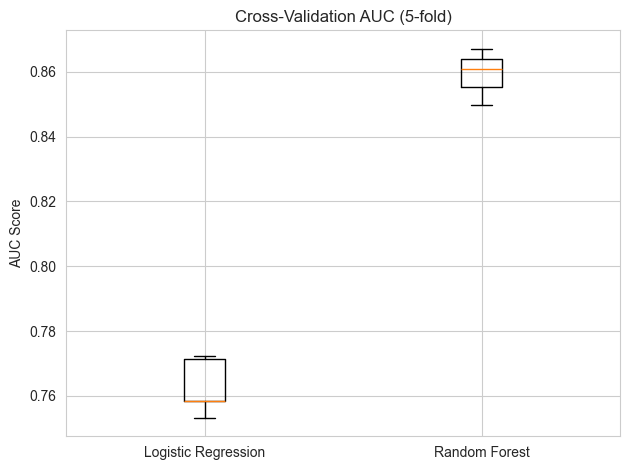

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

print(f"{'Model':<25}  CV AUC (mean ± std)")
print("-" * 48)

for name, model in models.items():
    # LR needs scaled features; RF doesn't
    X_cv = X_train_s if name == "Logistic Regression" else X_train
    scores = cross_val_score(model, X_cv, y_train, cv=cv, scoring="roc_auc")
    cv_results[name] = scores
    print(f"{name:<25}  {scores.mean():.4f} ± {scores.std():.4f}")

# Visualise CV spread
plt.boxplot([cv_results[m] for m in models], labels=models.keys())
plt.title("Cross-Validation AUC (5-fold)")
plt.ylabel("AUC Score")
plt.tight_layout()
plt.show()

In [10]:
results = []
trained_models = {}

for name, model in models.items():
    X_tr = X_train_s if name == "Logistic Regression" else X_train
    X_te = X_test_s  if name == "Logistic Regression" else X_test

    model.fit(X_tr, y_train)
    trained_models[name] = model

    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    results.append({
        "Model":     name,
        "AUC":       roc_auc_score(y_test, y_prob),
        "F1":        f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall":    recall_score(y_test, y_pred),
        "Accuracy":  accuracy_score(y_test, y_pred),
    })

results_df = (
    pd.DataFrame(results)
    .set_index("Model")
    .round(4)
    .sort_values("AUC", ascending=False)
)

print(results_df)
best_name = results_df.index[0]
print(f"\nBest model: {best_name}")

                        AUC      F1  Precision  Recall  Accuracy
Model                                                           
Random Forest        0.8704  0.5941     0.8128  0.4681    0.8695
Logistic Regression  0.7776  0.3144     0.6187  0.2108    0.8125

Best model: Random Forest


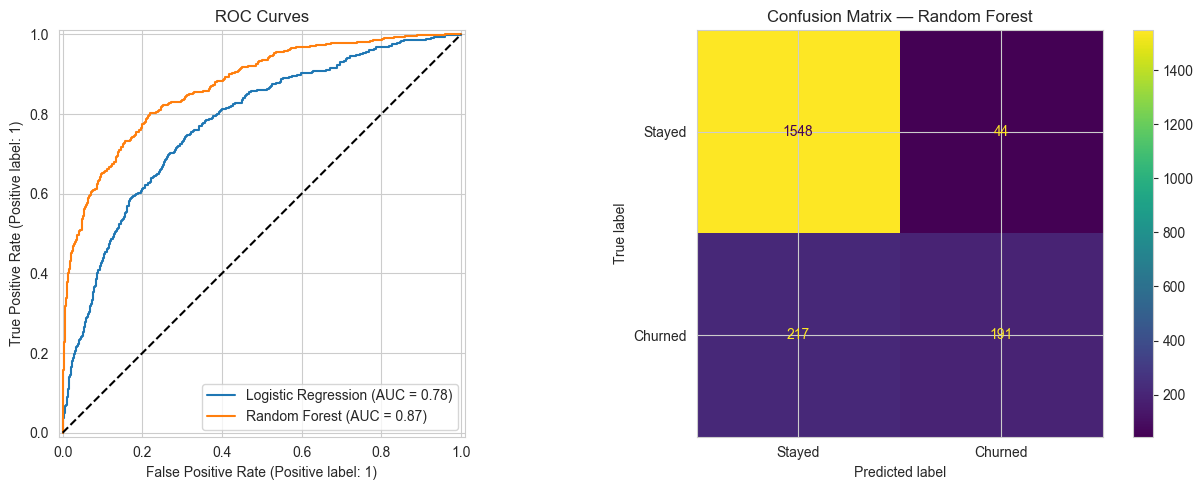


Classification Report — Random Forest
              precision    recall  f1-score   support

      Stayed       0.88      0.97      0.92      1592
     Churned       0.81      0.47      0.59       408

    accuracy                           0.87      2000
   macro avg       0.84      0.72      0.76      2000
weighted avg       0.86      0.87      0.86      2000



In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curves
for name, model in trained_models.items():
    X_te = X_test_s if name == "Logistic Regression" else X_test
    y_prob = model.predict_proba(X_te)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name, ax=axes[0])

axes[0].plot([0, 1], [0, 1], "k--")
axes[0].set_title("ROC Curves")

# Confusion matrix for the best model
best_model = trained_models[best_name]
X_te_best  = X_test_s if best_name == "Logistic Regression" else X_test
y_pred_best = best_model.predict(X_te_best)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=["Stayed", "Churned"],
    ax=axes[1]
)
axes[1].set_title(f"Confusion Matrix — {best_name}")

plt.tight_layout()
plt.show()

print(f"\nClassification Report — {best_name}")
print(classification_report(y_test, y_pred_best, target_names=["Stayed", "Churned"]))

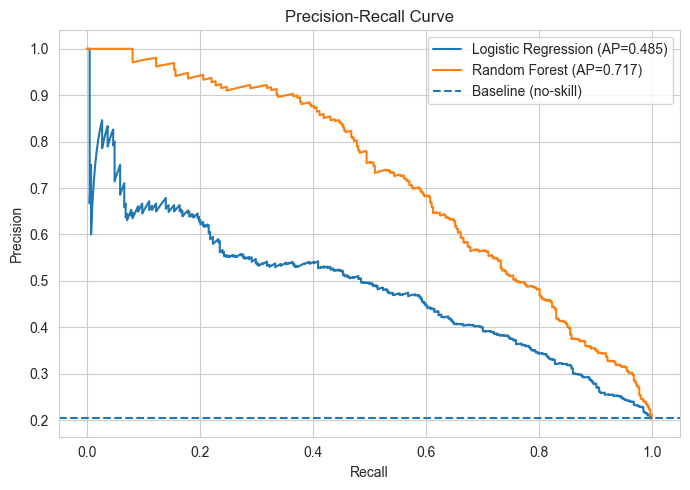

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))

for name, model in trained_models.items():
    X_te   = X_test_s if name == "Logistic Regression" else X_test
    y_prob = model.predict_proba(X_te)[:, 1]

    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax.plot(rec, prec, label=f"{name} (AP={ap:.3f})")

ax.axhline(y_test.mean(), linestyle="--", label="Baseline (no-skill)")
ax.set(xlabel="Recall", ylabel="Precision", title="Precision-Recall Curve")
ax.legend()
plt.tight_layout()
plt.show()

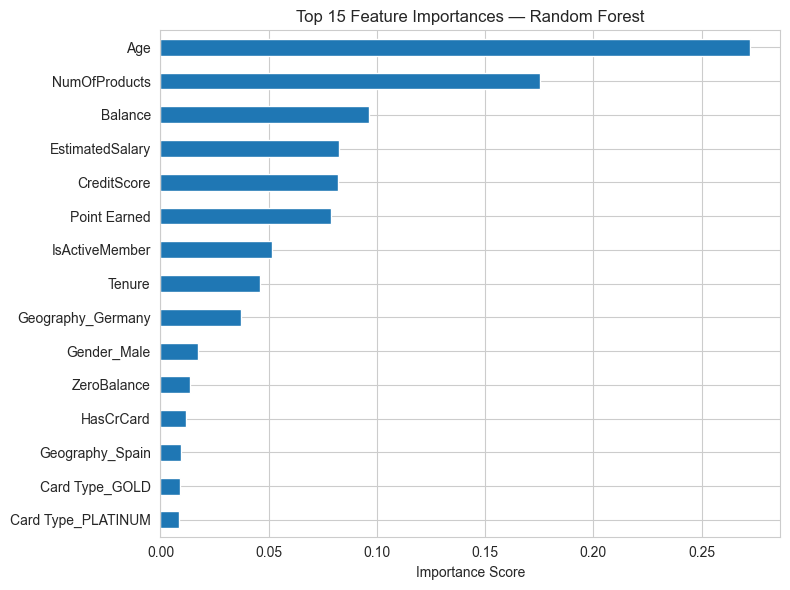

Top 10 features:
Age                  0.2726
NumOfProducts        0.1756
Balance              0.0961
EstimatedSalary      0.0827
CreditScore          0.0819
Point Earned         0.0788
IsActiveMember       0.0516
Tenure               0.0458
Geography_Germany    0.0374
Gender_Male          0.0174
dtype: float64


In [13]:
rf_model = trained_models["Random Forest"]

feat_imp = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feat_imp.head(15).sort_values().plot(kind="barh", figsize=(8, 6))
plt.title("Top 15 Feature Importances — Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(feat_imp.head(10).round(4))

In [14]:
os.makedirs("saved_models", exist_ok=True)

for name, model in trained_models.items():
    safe_name = name.replace(" ", "_")
    with open(f"saved_models/{safe_name}.pkl", "wb") as f:
        pickle.dump(model, f)
    print(f"Saved: {safe_name}.pkl")

with open("saved_models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("Saved: scaler.pkl")

with open("saved_models/feature_names.json", "w") as f:
    json.dump(list(X.columns), f, indent=2)
print("Saved: feature_names.json")

results_df.to_csv("saved_models/model_results.csv")
print("Saved: model_results.csv")

Saved: Logistic_Regression.pkl
Saved: Random_Forest.pkl
Saved: scaler.pkl
Saved: feature_names.json
Saved: model_results.csv


In [15]:
def assign_risk(prob):
    if prob >= 0.70:
        return "High"
    elif prob >= 0.45:
        return "Medium"
    return "Low"

# Load the best model
safe_best = best_name.replace(" ", "_")
with open(f"saved_models/{safe_best}.pkl", "rb") as f:
    loaded_model = pickle.load(f)

# Use the same scaling logic as during training
sample       = X_test.head(20).copy()
sample_input = X_test_s[:20] if best_name == "Logistic Regression" else sample

probs = loaded_model.predict_proba(sample_input)[:, 1]

output = pd.DataFrame({
    "Churn Probability": probs.round(3),
    "Risk Tier": [assign_risk(p) for p in probs],
    "Actual Churn": y_test.head(20).values,
})

print(f"Predictions — {best_name}")
print(output.to_string(index=False))

Predictions — Random Forest
 Churn Probability Risk Tier  Actual Churn
             0.225       Low             0
             0.106       Low             0
             0.129       Low             0
             0.140       Low             1
             0.051       Low             0
             0.609    Medium             1
             0.687    Medium             1
             0.171       Low             0
             0.029       Low             0
             0.046       Low             0
             0.252       Low             0
             0.035       Low             0
             0.207       Low             0
             0.228       Low             0
             0.070       Low             0
             0.204       Low             1
             0.026       Low             0
             0.044       Low             0
             0.046       Low             0
             0.453    Medium             1
